# Exercises for Chapter 14, "Working with logistic regression"

In [2]:
import itertools
import os
import sys

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import special

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [3]:
print(sys.version_info)

sys.version_info(major=3, minor=14, micro=4, releaselevel='final', serial=0)


In [4]:
prng_builder = bg_ros.PRNGBuilder("""
    This is Chapter 14, wherein our heroes work with logistic regression in
    fun and fascinating ways.  I'm doing these exercises well after actually
    reading the material so I'll have to page a lot of it back in as it goes.
    I think it's... mostly adding interaction features?  We'll see.
""")

## 14.1, Graphing binary data and logistic regression

> Reproduce Figure 14.1 with the model,
> $\text{Pr}(y =1) = \text{logit}^{-1}(0.4 - 0.3x)$, with 50 data points $x$
> sampled uniformly in the range $[A, B]$. (In Figure 14.1 the $x$’s were drawn
> from a normal distribution.) Choose the values $A$ and $B$ so that the plot
> includes a zone where values of $y$ are all 1, a zone where they are all 0,
> and a band of overlap in the middle.

In [5]:
rng = prng_builder.new('Exercise 14.1, reproducing a figure')

In [6]:
a, b = (0.4, -0.3)

In [7]:
# From the logistic probability density function, we want the latent
# linear-predictor variable z to range from -6 to 6.
hi = (-6 - a) / b
lo = (6 - a) / b
print(f'[A, B] = [{lo: 0.1f}, {hi: 0.1f}]')

[A, B] = [-18.7,  21.3]


In [8]:
xs = rng.uniform(low=lo, high=hi, size=50)
zs = a + b * xs
rs = rng.uniform(size=50)
ys = [1 if ri < si else 0 for (ri, si) in zip(rs, special.expit(zs))]

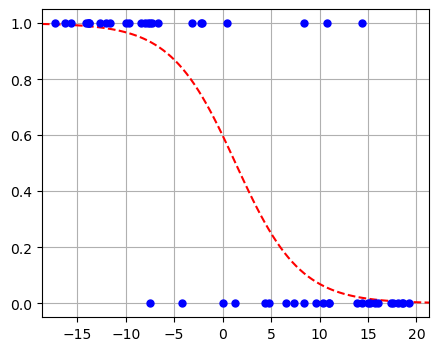

In [9]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(
    numpy.linspace(lo, hi, 100),
    special.expit(a + b * numpy.linspace(lo, hi, 100)),
    'r--',
)
ax.plot(xs, ys, 'b.', markersize=10)
ax.grid()
ax.set_xlim(lo, hi)
ax.set_axisbelow(True)
        

## 14.2, Logistic regression and discrimination lines

> Reproduce Figure 14.2 with the model,
> $\text{Pr}(y = 1) = \text{logit}^{-1}(0.4 - 0.3x_1 + 0.2x_2)$, with $(x1, x2)$
> sampled uniformly from the rectangle $[A_1, B_1] \times [A_2, B_2]$. Choose
> the values $A_1, B_1, A_2, B_2$ so that the plot includes a zone where values
> of $y$ are all 1, a zone where they are all 0, and a band of overlap in the
> middle, and with the three lines corresponding to
> $\text{Pr}(y = 1) = 0.1, 0.5,$ and 0.9 are all visible.

In [10]:
rng = prng_builder.new('Exercise 14.2, reproducing a whole nother figure')

In [11]:
a, b1, b2 = (0.4, -0.3, 0.2)
n = 150  # Num. points to sample

B1 = (-6 - a) / b1
A1 = (6 - a) / b1
A2 = (-6 - a) / b2
B2 = (6 - a) / b2

print(f'[A1, B1] = [{A1:0.1f}, {B1:0.1f}]')
print(f'[A2, B2] = [{A2:0.1f}, {B2:0.1f}]')

[A1, B1] = [-18.7, 21.3]
[A2, B2] = [-32.0, 28.0]


In [12]:
x1s = rng.uniform(low=A1, high=B1, size=n)
x2s = rng.uniform(low=A2, high=B2, size=n)
zs = a + b1 * x1s + b2 * x2s
rs = rng.uniform(size=n)
ys = [1 if ri < si else 0 for (ri, si) in zip(rs, special.expit(zs))]

In [13]:
def add_logreg_line(ax: pyplot.Axes, p: float, style: str):
    logit_p = special.logit(p)
    # a + b1 x1 + b2 x2 = logit_p
    # --> x2 = intercept + slope x1
    intercept = (logit_p - a) / b2
    slope = -1 * b1 / b2
    ax.plot(
        [A1, B1],
        [
            intercept + slope * A1,
            intercept + slope * B1,
        ],
        color='k',
        linestyle=style,
        linewidth=1,
        zorder=999,
    )

Text(0, 0.5, 'x2')

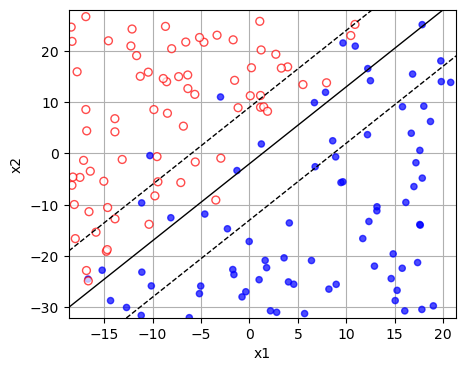

In [14]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
add_logreg_line(ax, 0.1, '--')
add_logreg_line(ax, 0.5, '-')
add_logreg_line(ax, 0.9, '--')
ax.scatter(
    x1s,
    x2s,
    s=[32 if yi == 1 else 20 for yi in ys],
    c=['w' if yi == 1 else 'b' for yi in ys],
    edgecolors=['r' if yi == 1 else 'b' for yi in ys],
    alpha=0.7,
)
ax.grid()
ax.set_xlim(lo, hi)
ax.set_axisbelow(True)
ax.set_xlim(A1, B1)
ax.set_ylim(A2, B2)
ax.set_xlabel('x1')
ax.set_ylabel('x2')

## 14.3, Graphing logistic regressions

> The well-switching data described in Section 13.7 are in the 
> [folder `Arsenic`](https://github.com/avehtari/ROS-Examples/tree/master/Arsenic/).
>
> (a) Fit a logistic regression for the probability of switching using
>     log(distance to nearest safe well) as a predictor.
>
> (b) Make a graph similar to Figure 13.8b displaying $\text{Pr(switch)}$ as a
>     function of distance to nearest safe well, along with the data.
>
> (c) Make a residual plot and binned residual plot as in Figure 14.8.
>
> (d) Compute the error rate of the fitted model and compare to the error rate
>     of the null model.
>
> (e) Create indicator variables corresponding to dist < 100; dist between 100
>     and 200; and dist > 200. Fit a logistic regression for $\text{Pr(switch)}$
>     using these indicators. With this new model, repeat the computations and
>     graphs for part (a) of this exercise.

In [15]:
rng = prng_builder.new('Exercise 14.3')

### Log(dist) model

In [16]:
wells_df = pandas.read_csv('/home/bgawalt/ros/datasets/wells.csv')
wells_model = bambi.Model("switch['1'] ~ log(dist)", wells_df, family="bernoulli")
wells_fit = wells_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(wells_fit, ["log(dist)",]))

Modeling the probability that switch==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, log(dist)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | 1.02 | 0.16
log(dist) | -0.20 | 0.04



In [17]:
dots_x = []
dots_y = []
for _, row in wells_df.iterrows():
    dots_x.append(row['dist'])
    y = row['switch']
    r = rng.uniform(0, 0.05)
    if y == 1:
        y -= r
    else:
        y += r
    dots_y.append(y)

wells_summ = arviz.summary(wells_fit)
a = wells_summ['mean']['Intercept']
b = wells_summ['mean']['log(dist)']
line_x = numpy.linspace(1, 350, 250)
line_y = special.expit(a + b * numpy.log(line_x))

Text(0, 0.5, 'Pr(switching)')

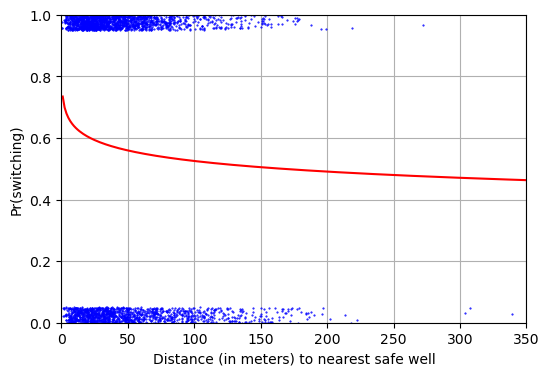

In [18]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
ax.plot(dots_x, dots_y, 'b.', markersize=1)
ax.plot(line_x, line_y, 'r-')
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(0, 350)
ax.set_ylim(0, 1)
ax.set_xlabel('Distance (in meters) to nearest safe well')
ax.set_ylabel('Pr(switching)')

In [19]:
wells_model.predict(wells_fit, data=wells_df)
wells_preds_df = wells_fit.posterior.mean(dim=['chain', 'draw'])['p'].to_dataframe()

In [20]:
preds_and_actuals = list(
    sorted(zip(wells_preds_df['p'], wells_df['switch'])))

In [21]:
bin_preds = []
bin_resids = []
bin_ses = []
batch_size = int(len(preds_and_actuals) / 40)
pos = 0
while pos < len(preds_and_actuals):
    batch = preds_and_actuals[pos : pos + batch_size]
    bin_preds.append(numpy.mean([p for p, _ in batch]))
    bin_resids.append(numpy.mean([a - p for p, a in batch]))
    p = numpy.mean([a for _, a in batch])
    bin_ses.append(2 * numpy.sqrt(p * (1 - p) / len(batch)))
    pos += batch_size

Text(0, 0.5, 'Average residual')

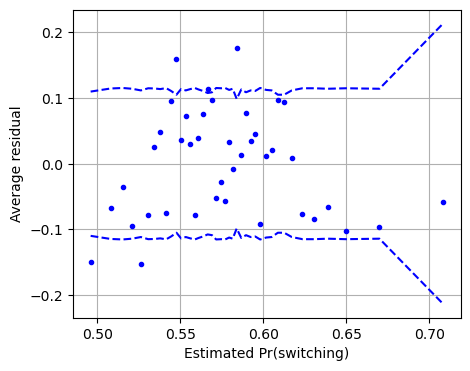

In [22]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(bin_preds, bin_resids, 'b.')
ax.plot(bin_preds, bin_ses, 'b--')
ax.plot(bin_preds, [-1 * se for se in bin_ses], 'b--')
ax.grid()
ax.set_xlabel('Estimated Pr(switching)')
ax.set_ylabel('Average residual')

In [23]:
null_p = numpy.mean([a for _, a in preds_and_actuals])
print(null_p)

0.5751655629139073


In [24]:
log_errors = 0
null_errors = 0
for p, a in preds_and_actuals:
    if p < 0.5 and a == 1:
        log_errors += 1
    if p > 0.5 and a == 0:
        log_errors += 1
    if a == 0:
        null_errors += 1
print(f'Model error rate: {100 * float(log_errors) / len(preds_and_actuals):0.1f}')
print(f'Null error rate: {100 * float(null_errors) / len(preds_and_actuals):0.1f}')

Model error rate: 41.9
Null error rate: 42.5


### Indicator variable model

In [25]:
wells2_df = pandas.DataFrame(data={
    'switch': wells_df['switch'],
    'dist_low': [(1 if (d < 100) else 0) for d in wells_df['dist']],
    'dist_mid': [(1 if (d >= 100 and d < 200) else 0) for d in wells_df['dist']],
    'dist_hi': [(1 if d > 200 else 0) for d in wells_df['dist']],
})

In [26]:
print(bg_ros.dataframe_describe_markdown(wells2_df))

|         | switch | dist_low | dist_mid | dist_hi
--------- | ------ | -------- | -------- | -------
**count** | 3020.00 | 3020.00 | 3020.00 | 3020.00
**mean**  | 0.58 | 0.90 | 0.10 | 0.00
**std**   | 0.49 | 0.30 | 0.30 | 0.05
**min**   | 0.00 | 0.00 | 0.00 | 0.00
**25%**   | 0.00 | 1.00 | 0.00 | 0.00
**50%**   | 1.00 | 1.00 | 0.00 | 0.00
**75%**   | 1.00 | 1.00 | 0.00 | 0.00
**max**   | 1.00 | 1.00 | 1.00 | 1.00



In [27]:
wells2_model = bambi.Model("switch['1'] ~ 0 + dist_low + dist_mid + dist_hi", wells2_df, family="bernoulli")
wells2_fit = wells2_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(wells2_fit, ["dist_low", "dist_mid", "dist_hi"]))

Modeling the probability that switch==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [dist_low, dist_mid, dist_hi]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | nan | nan
dist_low  | 0.37 | 0.04
dist_mid  | -0.28 | 0.12
dist_hi   | -1.44 | 0.93



In [28]:
wells2_summ = arviz.summary(wells2_fit)
b_low = wells2_summ['mean']['dist_low']
b_mid = wells2_summ['mean']['dist_mid']
b_hi = wells2_summ['mean']['dist_hi']
line_x = numpy.linspace(1, 350, 250)
line_y = []
for xi in line_x:
    if xi < 100:
        line_y.append(special.expit(b_low))
    elif xi < 200:
        line_y.append(special.expit(b_mid))
    else:
        line_y.append(special.expit(b_hi))

Text(0, 0.5, 'Pr(switching)')

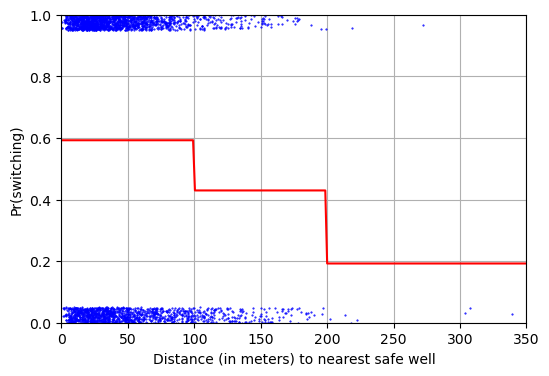

In [29]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
ax.plot(dots_x, dots_y, 'b.', markersize=1)
ax.plot(line_x, line_y, 'r-')
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(0, 350)
ax.set_ylim(0, 1)
ax.set_xlabel('Distance (in meters) to nearest safe well')
ax.set_ylabel('Pr(switching)')

In [30]:
wells2_model.predict(wells2_fit, data=wells2_df)
wells2_preds_df = wells2_fit.posterior.mean(dim=['chain', 'draw'])['p'].to_dataframe()

preds_and_actuals = list(zip(wells2_preds_df['p'], wells2_df['switch']))

ind_errors = 0
for p, a in preds_and_actuals:
    if p < 0.5 and a == 1:
        ind_errors += 1
    if p > 0.5 and a == 0:
        ind_errors += 1
print(f'Model error rate: {100 * float(ind_errors) / len(preds_and_actuals):0.1f}')
print(f'Null error rate: {100 * float(null_errors) / len(preds_and_actuals):0.1f}')

Model error rate: 40.9
Null error rate: 42.5


In [31]:
p = float(ind_errors) / len(preds_and_actuals)
se = numpy.sqrt(p * (1 - p) / len(preds_and_actuals))
print(f'[{100 * (p - 2 * se):0.1f}, {100 * (p + 2 * se):0.1f}]')

[39.1, 42.7]


## 14.5, Working with logistic regression

> In a class of 50 students, a logistic regression is performed of course grade
> (pass or fail) on midterm exam score (continuous values with mean 60 and
> standard deviation 15). The fitted model is
> $\text{Pr(pass)} = \text{logit}^{-1}(-24 + 0.4x)$.
> 
> (a) Graph the fitted model. Also on this graph put a scatterplot of
>     hypothetical data consistent with the information given.
> 
> (b) Suppose the midterm scores were transformed to have a mean of 0 and
>     standard deviation of 1. What would be the equation of the logistic
>     regression using these transformed scores as a predictor?
> 
> (c) Create a new predictor that is pure noise; for example, in R you can
>     create `newpred <- rnorm(n,0,1)`. Add it to your model. How much does the
>     leave-one-out cross validation score decrease?

In [32]:
rng = prng_builder.new('Exercise 14.5')

In [33]:
a, b = (-24, 0.4)
n = 50

In [34]:
xs = rng.normal(loc=60, scale=15, size=n)
zs = a + b * xs
rs = rng.uniform(size=n)
ys = [1 if ri < si else 0 for (ri, si) in zip(rs, special.expit(zs))]

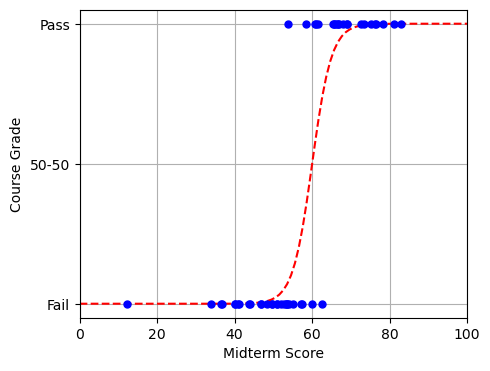

In [35]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(
    numpy.linspace(0, 100, 100),
    special.expit(a + b * numpy.linspace(0, 100, 100)),
    'r--',
)
ax.plot(xs, ys, 'b.', markersize=10)
ax.set_xlabel('Midterm Score')
ax.set_ylabel('Course Grade')
ax.set_yticks([0, 0.5, 1], ['Fail', '50-50', 'Pass'])
ax.grid()
ax.set_xlim(0, 100)
ax.set_axisbelow(True)

In [36]:
midterm_df = pandas.DataFrame(data={
    'midterm': xs,
    'course': ys,
    'noise': rng.normal(loc=60, scale=15, size=n)
})

In [37]:
mid1_model = bambi.Model("course['1'] ~ midterm", midterm_df, family='bernoulli')
mid1_fit = mid1_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(mid1_fit, ['midterm',]))

Modeling the probability that course==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, midterm]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -11.85 | 2.53
midterm   | 0.20 | 0.04



In [38]:
mid2_model = bambi.Model("course['1'] ~ midterm + noise", midterm_df, family='bernoulli')
mid2_fit = mid2_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(mid2_fit, ['midterm', 'noise']))

Modeling the probability that course==1
Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:3004: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, midterm, noise]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -10.52 | 2.76
midterm   | 0.21 | 0.04
noise     | -0.03 | 0.03



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

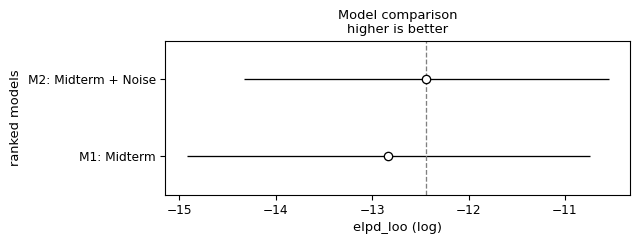

In [39]:
midterm_models = {
    'M1: Midterm': mid1_fit,
    'M2: Midterm + Noise': mid2_fit,
}
midterm_compare = arviz.compare(midterm_models)
arviz.plot_compare(midterm_compare)

## 14.6, Limitations of logistic regression

> Consider a dataset with $n = 20$ points, a single predictor $x$ that takes on
> the values $1, \ldots, 20$, and binary data $y$. Construct data values
> $y_1, \ldots, y_{20}$ that are inconsistent with any logistic regression on
> $x$. Fit a logistic regression to these data, plot the data and fitted curve,
> and explain why you can say that the model does not fit the data.

In [40]:
xs = [float(i) for i in range(20)]
ys = [i % 2 for i in range(20)]
limit_df = pandas.DataFrame(data={'x': xs, 'y': ys})

In [41]:
limit_model = bambi.Model("y['1'] ~ x", limit_df, family='bernoulli')
limit_fit = limit_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(limit_fit, ['x',]))

Modeling the probability that y==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, x]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -0.27 | 0.84
x         | 0.03 | 0.07



In [42]:
limit_summ = arviz.summary(limit_fit)
limit_a = limit_summ['mean']['Intercept']
limit_b = limit_summ['mean']['x']

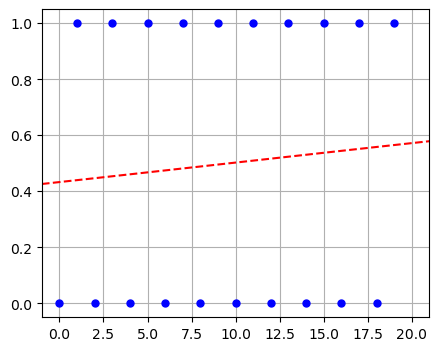

In [43]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(
    numpy.linspace(-1, 21, 100),
    special.expit(limit_a + limit_b * numpy.linspace(-1, 21, 100)),
    'r--',
)
ax.plot(xs, ys, 'b.', markersize=10)
ax.grid()
ax.set_xlim(-1, 21)
ax.set_axisbelow(True)

In [44]:
limit_null_model = bambi.Model("y['1'] ~ 1", limit_df, family='bernoulli')
limit_null_fit = limit_null_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(limit_null_fit, ['Intercept']))

Modeling the probability that y==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -0.01 | 0.44
Intercept | -0.01 | 0.44



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

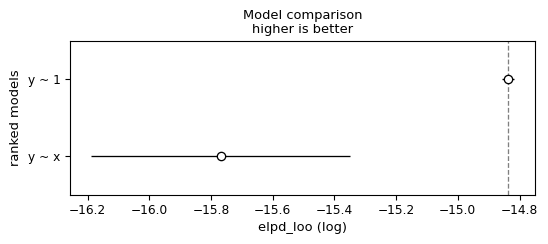

In [45]:
limit_models = {
    'y ~ x': limit_fit,
    'y ~ 1': limit_null_fit,
}
limit_compare = arviz.compare(limit_models)
arviz.plot_compare(limit_compare)

## 14.7, Model building and comparison

> Continuing with the well-switching example:
>
> (a) Fit a logistic regression for the probability of switching using, as
>     predictors, distance, log(arsenic), and their interaction. Interpret the
>     estimated coefficients and their standard errors.
> 
> (b) Make graphs as in Figure 14.3 to show the relation between probability of
>     switching, distance, and arsenic level.
> 
> (c) Following the procedure described in Section 14.4, compute the average
>     predictive differences corresponding to:
> 
>     i. A comparison of `dist` = 0 to `dist` = 100, with `arsenic` held
>         constant.
> 
>     ii. A comparison of `dist` = 100 to `dist` = 200, with `arsenic` held
>         constant.
> 
>     iii. A comparison of `arsenic` = 0.5 to `arsenic` = 1.0, with `dist` held
>         constant.
> 
>     iv. A comparison of `arsenic` = 1.0 to `arsenic` = 2.0, with `dist` held
>         constant.
> 
> Discuss these results.

In [46]:
rng = prng_builder.new('Exercise 14.7')

In [47]:
wells_df['log_arsenic'] = numpy.log(wells_df['arsenic'])
wells_df.describe()

,switch,arsenic,dist,dist100,assoc,educ,educ4,log_arsenic
count,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000
mean,0.575166,1.656930,48.331863,0.483319,0.422848,4.828477,1.207119,0.313861
std,0.494400,1.107387,38.478675,0.384787,0.494093,4.017317,1.004329,0.608637
min,0.000000,0.510000,0.387000,0.003870,0.000000,0.000000,0.000000,-0.673345
25%,0.000000,0.820000,21.117250,0.211172,0.000000,0.000000,0.000000,-0.198451
50%,1.000000,1.300000,36.761499,0.367615,0.000000,5.000000,1.250000,0.262364
75%,1.000000,2.200000,64.041000,0.640410,1.000000,8.000000,2.000000,0.788457
max,1.000000,9.650000,339.531006,3.395310,1.000000,17.000000,4.250000,2.266958


In [48]:
print(bg_ros.dataframe_describe_markdown(wells_df, ('switch', 'arsenic', 'dist')))

|         | switch | arsenic | dist
--------- | ------ | ------- | ----
**count** | 3020.00 | 3020.00 | 3020.00
**mean**  | 0.58 | 1.66 | 48.33
**std**   | 0.49 | 1.11 | 38.48
**min**   | 0.00 | 0.51 | 0.39
**25%**   | 0.00 | 0.82 | 21.12
**50%**   | 1.00 | 1.30 | 36.76
**75%**   | 1.00 | 2.20 | 64.04
**max**   | 1.00 | 9.65 | 339.53



In [49]:
wells3_model = bambi.Model("switch['1'] ~ dist100 + log_arsenic + dist100:log_arsenic", wells_df, family="bernoulli")
wells3_fit = wells3_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(wells3_fit, ["dist100", "log_arsenic", "dist100:log_arsenic"]))

Modeling the probability that switch==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dist100, log_arsenic, dist100:log_arsenic]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.               | Mean   | s.e.
------------------- | ------ | ------
sigma               | nan | nan
Intercept           | 0.49 | 0.07
dist100             | -0.88 | 0.14
log_arsenic         | 0.97 | 0.11
dist100:log_arsenic | -0.22 | 0.18



In [50]:
wells3_summ = arviz.summary(wells3_fit)
wells3_means = wells3_summ['mean']
a = wells3_means['Intercept']
b_d100 = wells3_means['dist100']
b_logars = wells3_means['log_arsenic']
b_inter = wells3_means['dist100:log_arsenic']

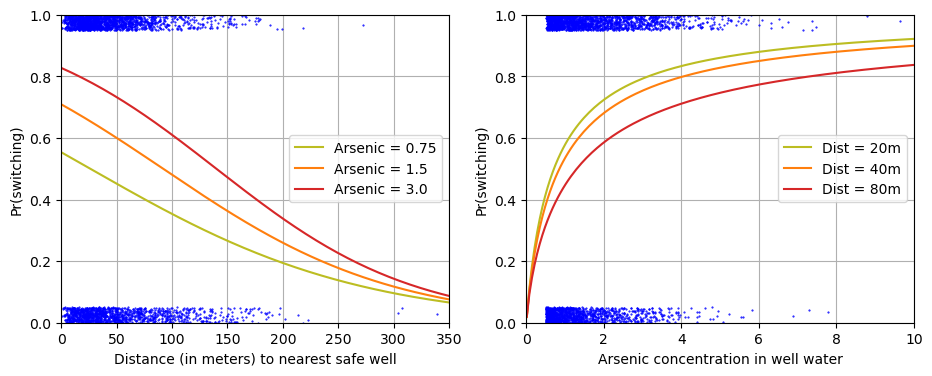

In [51]:
fig, axs = pyplot.subplots(nrows=1, ncols=2, figsize=(11, 4))
cs = ['tab:olive', 'tab:orange', 'tab:red']

axs[0].plot(wells_df['dist'], dots_y, 'b.', markersize=1)
ds = numpy.linspace(0, 350, 150)
for arsenic, color in zip((0.75, 1.5, 3.0), cs):
    log_ars = numpy.log(arsenic)
    inters = (ds / 100) * log_ars
    preds = special.expit(
        a + b_d100 * (ds / 100) + b_logars * log_ars + b_inter * inters
    )
    axs[0].plot(ds, preds, linestyle='-', color=color, label=f'Arsenic = {arsenic}')
axs[0].set_xlim(0, 350)
axs[0].set_xlabel('Distance (in meters) to nearest safe well')

axs[1].plot(wells_df['arsenic'], dots_y, 'b.', markersize=1)
ars = numpy.linspace(0.01, 10, 150)
log_ars = numpy.log(ars)
for dist, color in zip((20, 40, 80), cs):
    d100 = dist / 100
    inters = d100 * log_ars
    preds = special.expit(
        a + b_d100 * d100 + b_logars * log_ars + b_inter * inters
    )
    axs[1].plot(ars, preds, linestyle='-', color=color, label=f'Dist = {dist}m')
axs[1].set_xlabel('Arsenic concentration in well water')
axs[1].set_xlim(0, 10)

for ax in axs:
    ax.grid()
    ax.set_axisbelow(True)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Pr(switching)')
    ax.legend()

In [54]:
pred_d0 = special.expit(
    a + b_d100 * 0 + b_logars * wells_df['log_arsenic'] + b_inter * 0 * wells_df['log_arsenic']
)
pred_d100 = special.expit(
    a + b_d100 * 1 + b_logars * wells_df['log_arsenic'] + b_inter * 1 * wells_df['log_arsenic']
)
pred_d200 = special.expit(
    a + b_d100 * 2 + b_logars * wells_df['log_arsenic'] + b_inter * 2 * wells_df['log_arsenic']
)

print('Avg. diff, dist 0m -> dist 100m:', numpy.mean(pred_d0 - pred_d100))
print('Avg. diff, dist 100m -> dist 200m:', numpy.mean(pred_d100 - pred_d200))

Avg. diff, dist 0m -> dist 100m: 0.21220359399890792
Avg. diff, dist 100m -> dist 200m: 0.2090501915772674


In [52]:
pred_ars05 = special.expit(
    a + b_d100 * wells_df['dist100'] + b_logars * numpy.log(0.5) + b_inter * wells_df['dist100'] * numpy.log(0.5)
)
pred_ars10 = special.expit(
    a + b_d100 * wells_df['dist100'] + b_logars * numpy.log(1) + b_inter * wells_df['dist100'] * numpy.log(1)
)
pred_ars20 = special.expit(
    a + b_d100 * wells_df['dist100'] + b_logars * numpy.log(2) + b_inter * wells_df['dist100'] * numpy.log(1)
)

print('Avg. diff, ars 0.5 -> ars 1.0:', numpy.mean(pred_ars10 - pred_ars05))
print('Avg. diff, ars 1.0 -> ars 2.0:', numpy.mean(pred_ars20 - pred_ars10))

Avg. diff, ars 0.5 -> ars 1.0: 0.14569456958230637
Avg. diff, ars 1.0 -> ars 2.0: 0.15674342149510542


## 14.9, Linear or logistic regression for discrete data

> Simulate continuous data from the regression model,
> $z = a + bx + \text{error}$. Set the parameters so that the outcomes $z$ are
> positive about half the time and negative about half the time.
> 
> (a) Create a binary variable $y$ that equals 1 if $z$ is positive or 0 if $z$
>     is negative. Fit a logistic regression predicting $y$ from $x$.
> 
> (b) Fit a linear regression predicting $y$ from $x$: you can do this, even
>     though the data $y$ are discrete.
> 
> (c) Estimate the average predictive comparison -- the expected difference in
>     $y$, corresponding to a unit difference in $x$ -- based on the fitted
>     logistic regression in (a). Compare this average predictive comparison to
>     the linear regression coefficient in (b).

In [65]:
rng = prng_builder.new('Exercise 14.9')

In [66]:
a = 0.4
b = 0.2
n = 75
xs = rng.normal(loc=-2, scale=1.5, size=n)
zs = a + b * xs
ys = numpy.where(zs > 0, 1, 0)

In [67]:
condisc_df = pandas.DataFrame(data={'y': ys, 'x': xs})

In [68]:
condisc_linear_model = bambi.Model("y ~ x", condisc_df)
condisc_linear_fit = condisc_linear_model.fit()
print(bg_ros.bambi_markdown(condisc_linear_fit, ["x",]))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 0.30 | 0.03
Intercept | 1.08 | 0.07
x         | 0.29 | 0.03



In [71]:
condisc_logreg_model = bambi.Model("y['1'] ~ x", condisc_df, family="bernoulli")
condisc_logreg_fit = condisc_logreg_model.fit()
print(bg_ros.bambi_markdown(condisc_logreg_fit, ["x",]))

Modeling the probability that y==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, x]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | 4.99 | 0.98
x         | 2.52 | 0.44



In [72]:
condisc_logreg_summ = arviz.summary(condisc_logreg_fit)
a = condisc_logreg_summ['mean']['Intercept']
b = condisc_logreg_summ['mean']['x']

pred_lo = special.expit(a + b * condisc_df['x'])
pred_hi = special.expit(a + b * condisc_df['x'] + b)
print(numpy.mean(pred_hi - pred_lo))

0.25300272114280253


## 14.10,  Linear or logistic regression for discrete data

> In the setup of the previous exercise:
> 
> (a) Set the parameters of your simulation so that the coefficient estimate in
>     (b) and the average predictive comparison in (c) are close.
> 
> (b) Set the parameters of your simulation so that the coefficient estimate in
>     (b) and the average predictive comparison in (c) are much different.
> 
> (c) In general, when will it work reasonably well to fit a linear model to
>     predict a binary outcome?
> 
> See also Exercise 13.12.

In [81]:
rng = prng_builder.new('Exercise 14.9')

In [82]:
xs = 8 * rng.choice(2, n) + rng.normal(size=n) - 4
zs = a + b * xs
ys = numpy.where(zs > 0, 1, 0)
print(numpy.mean(ys))

0.41333333333333333


In [83]:
condisc_df = pandas.DataFrame(data={'y': ys, 'x': xs})

In [84]:
condisc_linear_model = bambi.Model("y ~ x", condisc_df)
condisc_linear_fit = condisc_linear_model.fit()
print(bg_ros.bambi_markdown(condisc_linear_fit, ["x",]))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 0.12 | 0.01
Intercept | 0.48 | 0.01
x         | 0.12 | 0.00



In [85]:
condisc_logreg_model = bambi.Model("y['1'] ~ x", condisc_df, family="bernoulli")
condisc_logreg_fit = condisc_logreg_model.fit()
print(bg_ros.bambi_markdown(condisc_logreg_fit, ["x",]))

Modeling the probability that y==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, x]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -0.14 | 0.51
x         | 0.85 | 0.14



In [86]:
condisc_logreg_summ = arviz.summary(condisc_logreg_fit)
a = condisc_logreg_summ['mean']['Intercept']
b = condisc_logreg_summ['mean']['x']

pred_lo = special.expit(a + b * condisc_df['x'])
pred_hi = special.expit(a + b * condisc_df['x'] + b)
print(numpy.mean(pred_hi - pred_lo))

0.040810416088578244
